# InforMoViz
## My Letterboxd Diary Analysis

This notebook shows how I explored and cleaned my personal movie data, using my letterboxed diary and reviews, enriching them for countries and geners via TMDB API . Each section is a step in understanding my movie-watching habits.

## 1. Setup and Data Loading
Before I make any charts, I needed to load the right tools (like Pandas and Seaborn), and moving forward, as i needed more libraries, I gathered thrm all in this section. I also set a clean, white background so all the charts look neat and easy to read from start to finish.

In [86]:
%pip install matplotlib seaborn numpy pandas squarify plotly nbformat ipykernel --upgrade

Note: you may need to restart the kernel to use updated packages.


## 2. Combining and Enriching the Data
I downloaded two files directly from the Letterboxd app: one with the dates I watched movies (diary.csv) and one with the text I wrote about them (reviews.csv). Here, I combine them into one main dataset so I can analyze everything together.
Then as I was planning to do further analysis, my original data didn't have any information about movie genres or where the movies were made. To fix this, I wrote a script that connects to an online movie database (the TMDB API, as Letterboxd wasn't offering this kind of API service. With a little research, I found out about the TMDB API). This script automatically searches for every single movie I watched and adds its genres and production countries to my dataset so I can map and analyze them later.

In [ ]:
# all imports
import pandas as pd
import requests
import time
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# CONFIGURATION
DIARY_PATH = 'Dataset/diary.csv'
REVIEWS_PATH = 'Dataset/reviews.csv'
MAIN_PATH = 'Dataset/main.csv'
OUTPUT_PATH = 'Dataset/main_enriched_full.csv'

TMDB_API_KEY = 'ae4d6f343f7d9d8c3fb101ac0feda1dd'
BASE_URL = 'https://api.themoviedb.org/3'


# STEP 1: MERGE DIARY AND REVIEWS
def merge_datasets():
    print("--- Step 1: Merging Diary and Reviews ---")
    if not os.path.exists(DIARY_PATH) or not os.path.exists(REVIEWS_PATH):
        print(f"Error: Required files not found.")
        return None

    diary_df = pd.read_csv(DIARY_PATH)
    reviews_df = pd.read_csv(REVIEWS_PATH)
    reviews_subset = reviews_df[['Letterboxd URI', 'Review']]
    main_df = pd.merge(diary_df, reviews_subset, on='Letterboxd URI', how='left')
    main_df.to_csv(MAIN_PATH, index=False)
    return main_df

# STEP 2: TMDB API ENRICHMENT (GENRES & COUNTRIES)
def fetch_movie_details(movie_name, year):
    search_url = f"{BASE_URL}/search/movie"
    params = {'api_key': TMDB_API_KEY, 'query': movie_name, 'year': year}

    try:
        search_response = requests.get(search_url, params=params)
        search_response.raise_for_status()
        results = search_response.json().get('results', [])

        if not results:
            return "Unknown", "Unknown"

        movie_id = results[0]['id']
        details_url = f"{BASE_URL}/movie/{movie_id}"
        details_response = requests.get(details_url, params={'api_key': TMDB_API_KEY})
        details_response.raise_for_status()
        details = details_response.json()

        genres = [g['name'] for g in details.get('genres', [])]
        genre_str = ", ".join(genres) if genres else "Unknown"

        countries = [c['name'] for c in details.get('production_countries', [])]
        country_str = ", ".join(countries) if countries else "Unknown"

        return genre_str, country_str

    except Exception as e:
        return "Error", "Error"

if __name__ == "__main__":
    main_df = merge_datasets()
    
    if main_df is not None:
        print(f"Fetching details for {len(main_df)} movies...")
        genres_list = []
        countries_list = []
        
        for index, row in main_df.iterrows():
            name = row['Name']
            year = int(row['Year']) if pd.notnull(row['Year']) else None
            print(f"[{index + 1}/{len(main_df)}] Fetching: {name} ({year})...")
            
            genres, countries = fetch_movie_details(name, year)
            genres_list.append(genres)
            countries_list.append(countries)
            time.sleep(0.1) 

        main_df['Genre'] = genres_list
        main_df['Country'] = countries_list
        main_df.to_csv(OUTPUT_PATH, index=False)
        print(f"\nDone! Enriched dataset saved to: {OUTPUT_PATH}")


--- Step 1: Merging Diary and Reviews ---
Fetching details for 198 movies...
[1/198] Fetching: Roma (2018)...
[2/198] Fetching: Gravity (2013)...
[3/198] Fetching: The Square (2017)...
[4/198] Fetching: Manchester by the Sea (2016)...
[5/198] Fetching: The Lobster (2015)...
[6/198] Fetching: Blue Valentine (2010)...
[7/198] Fetching: The Big Lebowski (1998)...
[8/198] Fetching: GoodFellas (1990)...
[9/198] Fetching: A Beautiful Mind (2001)...
[10/198] Fetching: 2046 (2004)...
[11/198] Fetching: Chemical Hearts (2020)...
[12/198] Fetching: Allied (2016)...
[13/198] Fetching: One Day (2011)...
[14/198] Fetching: The Hangover (2009)...
[15/198] Fetching: The Hangover Part II (2011)...
[16/198] Fetching: Three Monkeys (2008)...
[17/198] Fetching: La Dolce Vita (1960)...
[18/198] Fetching: Catch Me If You Can (2002)...
[19/198] Fetching: Memories of Murder (2003)...
[20/198] Fetching: 8 Mile (2002)...
[21/198] Fetching: WandaVision (2021)...
[22/198] Fetching: I Care a Lot (2020)...
[23/198

### A view of the data

In [116]:

# Load the dataset
df = pd.read_csv('Dataset/main_enriched_full.csv')
print(f"Dataset loaded with {len(df)} entries.")
df.head()

Dataset loaded with 198 entries.


,Date,Name,Year,Letterboxd URI,Rating,Rewatch,Tags,Watched Date,Review,Genre,Country
0,2020-08-12,Roma,2018,https://boxd.it/1it1ZR,3.0,NaN,NaN,2020-08-12,NaN,Drama,"United Kingdom, United States of America"
1,2020-08-13,Gravity,2013,https://boxd.it/1izFE7,2.0,NaN,NaN,2020-08-13,NaN,"Science Fiction, Thriller, Drama","United Kingdom, United States of America"
2,2020-08-19,The Square,2017,https://boxd.it/1jbB6h,3.0,NaN,NaN,2020-08-18,Christian was hot 🙂,Drama,"Denmark, France, Germany, Sweden, United State..."
3,2020-08-19,Manchester by the Sea,2016,https://boxd.it/1jcrzP,4.0,NaN,NaN,2020-08-19,One of the few movies that made me cry.,Drama,United States of America
4,2020-08-20,The Lobster,2015,https://boxd.it/1jgM6R,3.0,NaN,NaN,2020-08-20,Fuck that loner leader.,"Comedy, Drama, Romance","France, Greece, Ireland, Netherlands, United K..."


## 3. Cleaning the Data
Here, after a trial, I decided to change the raw date text into an actual time format, so I can easily pull out the "Year" and "Month" for my timeline charts.

In [132]:
# Convert 'Watched Date' to datetime objects so we can extract the year
df['Watched Date'] = pd.to_datetime(df['Watched Date'])
df['Watched Year'] = df['Watched Date'].dt.year


## 4.A Movie Genres (Pie Chart Attempt)
My first idea was to use a pie chart to see which movie genres I watch the most. I was assuming there are few of them.

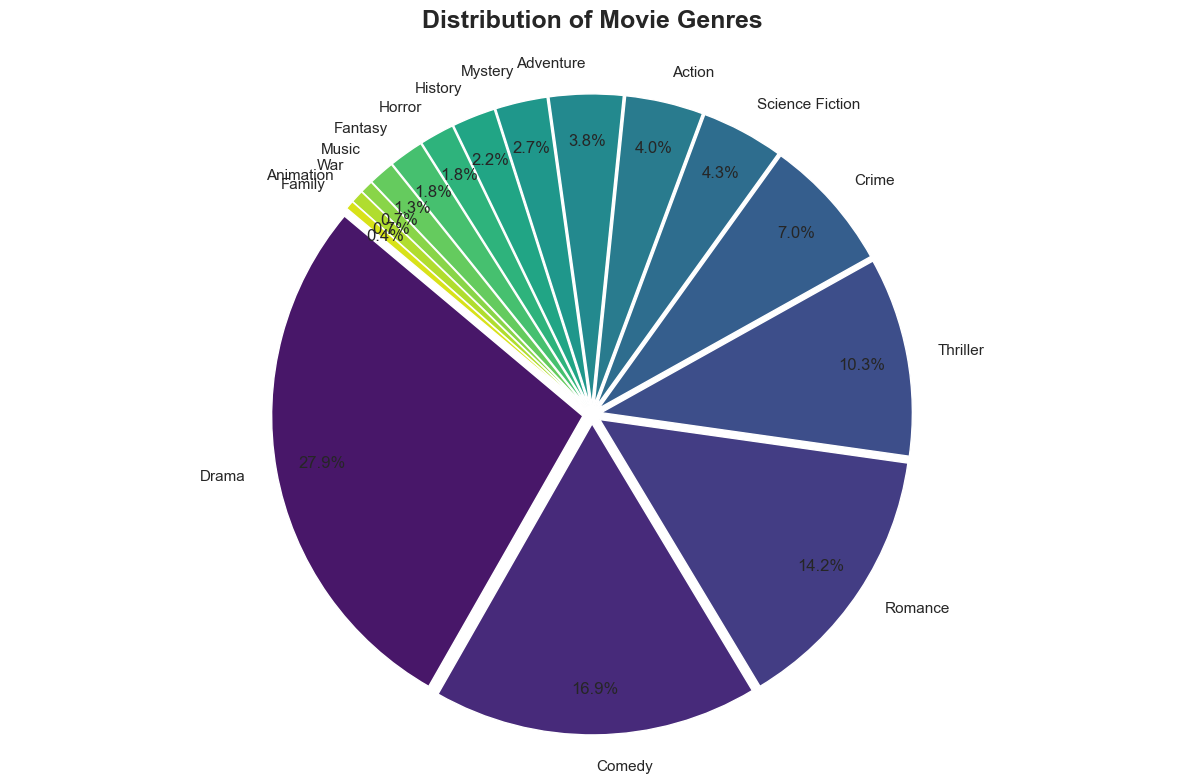

In [ ]:
# Process genres (splitting and exploding multi-genre entries)
df_genres = df[df['Genre'].notna() & (df['Genre'] != 'Unknown')].copy()
genre_counts = df_genres['Genre'].str.split(', ').explode().value_counts()

# Create a Donut Chart
fig, ax = plt.subplots()
colors = sns.color_palette('viridis', len(genre_counts))

wedges, texts, autotexts = ax.pie(
    genre_counts, 
    labels=genre_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    pctdistance=0.85,
    explode=[0.03] * len(genre_counts)
)

# Add center circle for donut look
#centre_circle = plt.Circle((0,0), 0.70, fc='white')
#ax.add_artist(centre_circle)

plt.title('Distribution of Movie Genres', fontsize=18, fontweight='bold', pad=25)
plt.axis('equal') 
plt.tight_layout()
plt.show()

## 4.B Movie Genres (Treemap)
After making the pie chart, I realized there were way too many genres to fit neatly in a circle, 16 precisely. The slices were too thin and hard to read. For a better visual, I chose a Treemap. It uses boxes of different sizes, which makes it much easier for the eye to compare amounts.

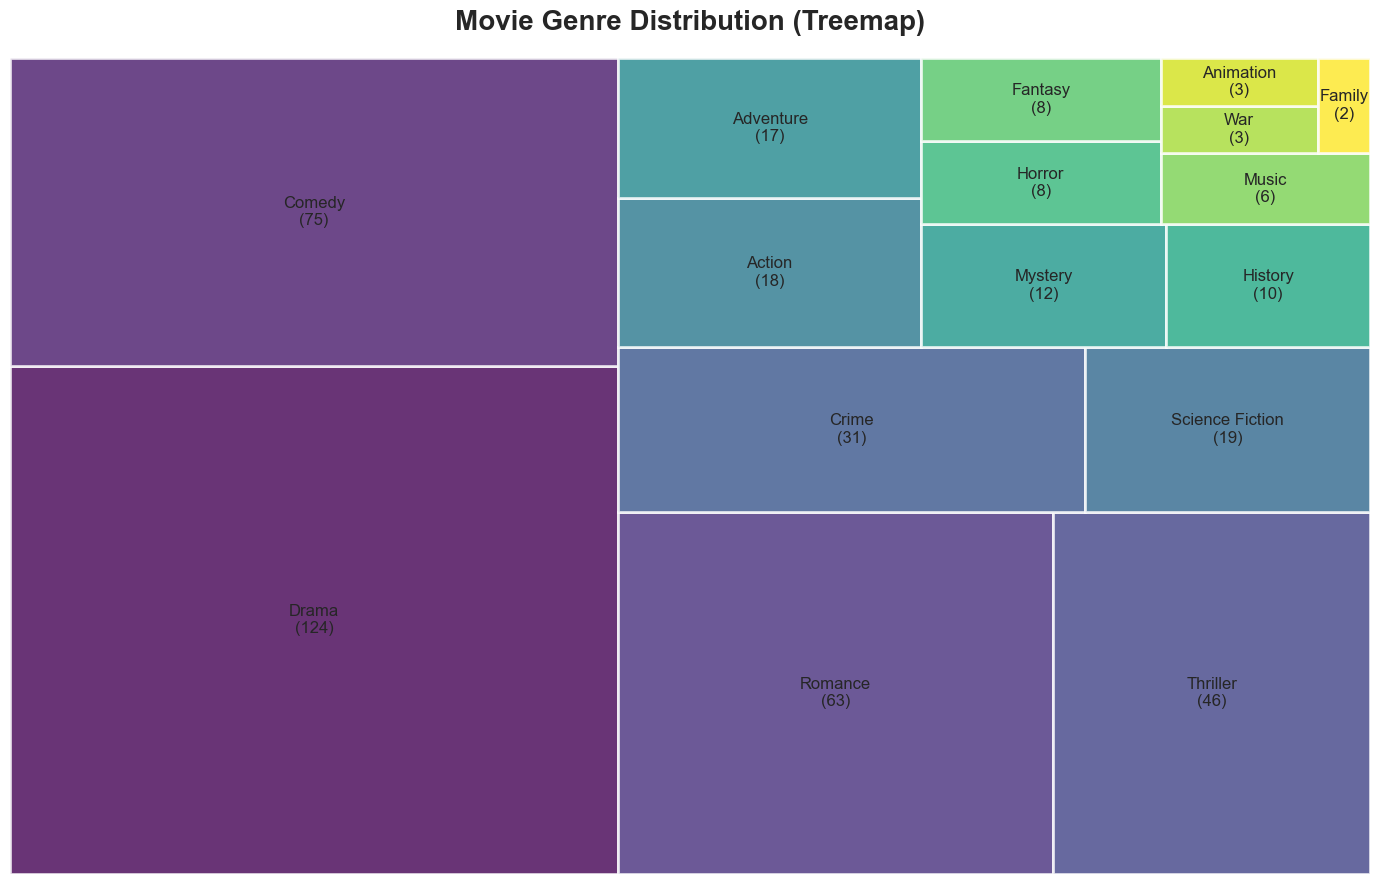

In [ ]:


#  Process the genres (split and explode)
df_genres = df[df['Genre'].notna() & (df['Genre'] != 'Unknown')].copy()
genre_series = df_genres['Genre'].str.split(', ').explode()
genre_counts = genre_series.value_counts()

# Prepare labels and colors
# combine the genre name and the count for the label
labels = [f'{genre}\n({count})' for genre, count in zip(genre_counts.index, genre_counts.values)]
colors = plt.cm.viridis(np.linspace(0, 1, len(genre_counts)))

# Create the Treemap
plt.figure(figsize=(14, 9))

squarify.plot(
    sizes=genre_counts.values, 
    label=labels, 
    alpha=0.8, 
    color=colors,
    edgecolor="white",
    linewidth=2
)

plt.title('Movie Genre Distribution (Treemap)', fontsize=20, fontweight='bold', pad=20)
plt.axis('off') 

plt.tight_layout()
plt.show()


## 5. My Movie Ratings
To see how many movies I gave 1 star, 2 stars, 5 stars, etc., a Bar Chart was the perfect choice. Because ratings are just simple categories, bars make it very easy to compare the amounts side-by-side.

/var/folders/4t/r2dg52q53m5_t64tj26d8ljm0000gn/T/ipykernel_11817/163529546.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rating', palette='viridis')


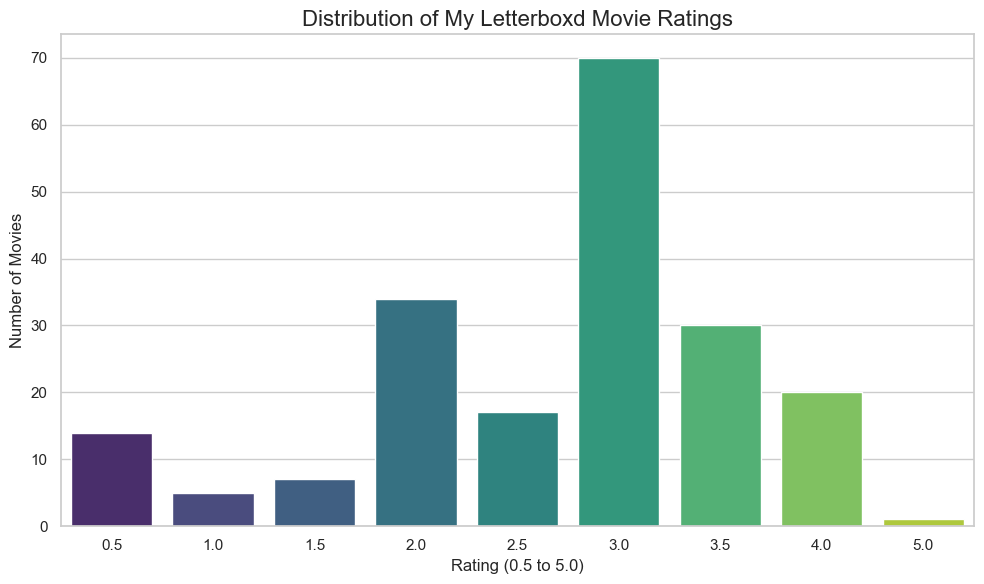

In [92]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Rating', palette='viridis')
plt.title('Distribution of My Letterboxd Movie Ratings', fontsize=16)
plt.xlabel('Rating (0.5 to 5.0)', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.tight_layout()
plt.show()

## 6.A Movies Watched Per Year
Tracking how my movie viewing volume changes over the years. As mydiary dates back to 2020, there are only 7 years to cover, which can be easily visualized and be compared in a bar chart.

/var/folders/4t/r2dg52q53m5_t64tj26d8ljm0000gn/T/ipykernel_11817/445926761.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=movies_per_year.index.astype(int), y=movies_per_year.values, palette='magma')


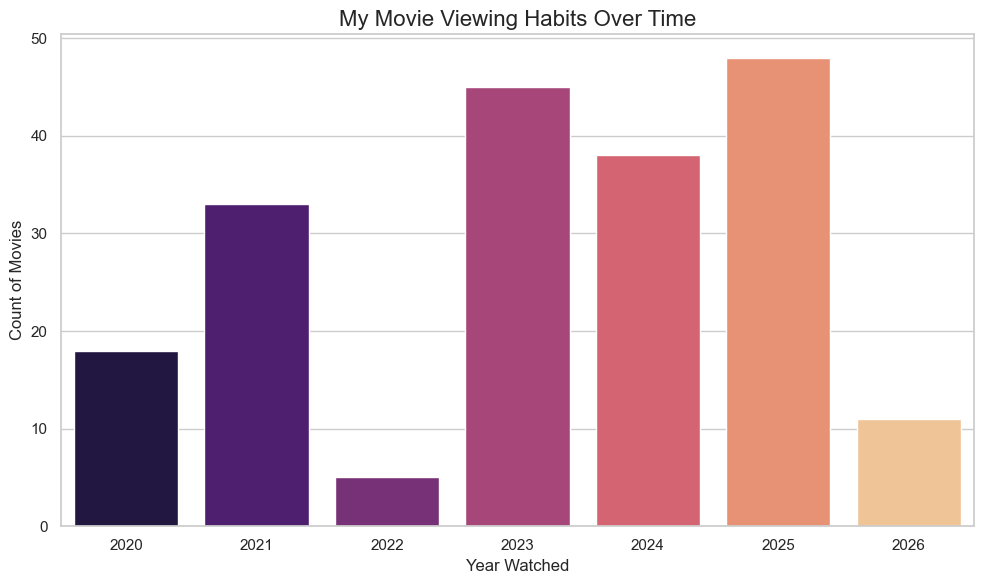

In [93]:
# Ensuring 'Watched Date' is a datetime object and extract the year
df['Watched Date'] = pd.to_datetime(df['Watched Date'])
df['Watched Year'] = df['Watched Date'].dt.year

plt.figure(figsize=(10, 6))
movies_per_year = df['Watched Year'].value_counts().sort_index()

sns.barplot(x=movies_per_year.index.astype(int), y=movies_per_year.values, palette='magma')

plt.title('My Movie Viewing Habits Over Time', fontsize=16)
plt.xlabel('Year Watched', fontsize=12)
plt.ylabel('Count of Movies', fontsize=12)
plt.tight_layout()
plt.show()


## 6.B Watching Habits by Month and Year
I wanted to see when I watch the most movies. First, I tried a grouped bar chart.


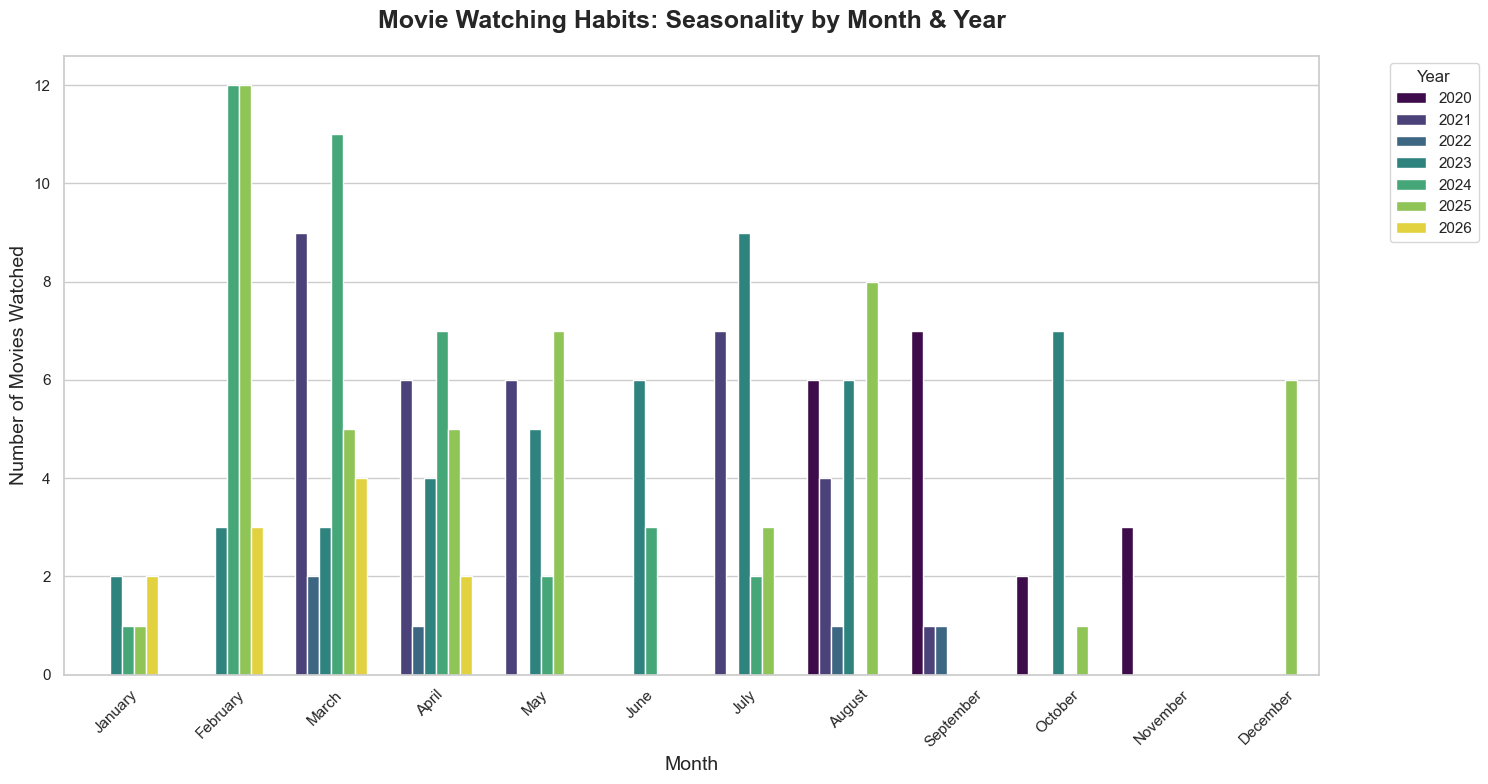

In [ ]:


# Load the Data
df = pd.read_csv('Dataset/main_enrichedwithcountry_full.csv')
df['Watched Date'] = pd.to_datetime(df['Watched Date'])

# Extract Month Name and Year
df['Month'] = df['Watched Date'].dt.month_name()
df['Year'] = df['Watched Date'].dt.year

# Define the correct order for months (so they don't appear alphabetically)
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Group the data to get the counts per month/year
monthly_habits = df.groupby(['Year', 'Month']).size().reset_index(name='Movie Count')

# Create the Grouped Bar Chart
plt.figure(figsize=(15, 8))
sns.barplot(
    data=monthly_habits, 
    x='Month', 
    y='Movie Count', 
    hue='Year', 
    order=month_order, 
    palette='viridis'
)

# Formatting the chart
plt.title('Movie Watching Habits: Seasonality by Month & Year', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of Movies Watched', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()


## 6.C Watching Habits (Calendar Chart)
After seeing the previous chart, I decided a calendar heatmap was a much better choice. It makes it very easy to compare every month across different years. By using darker colors for higher numbers, the busiest movie-watching months are easily discoverable in a glance.

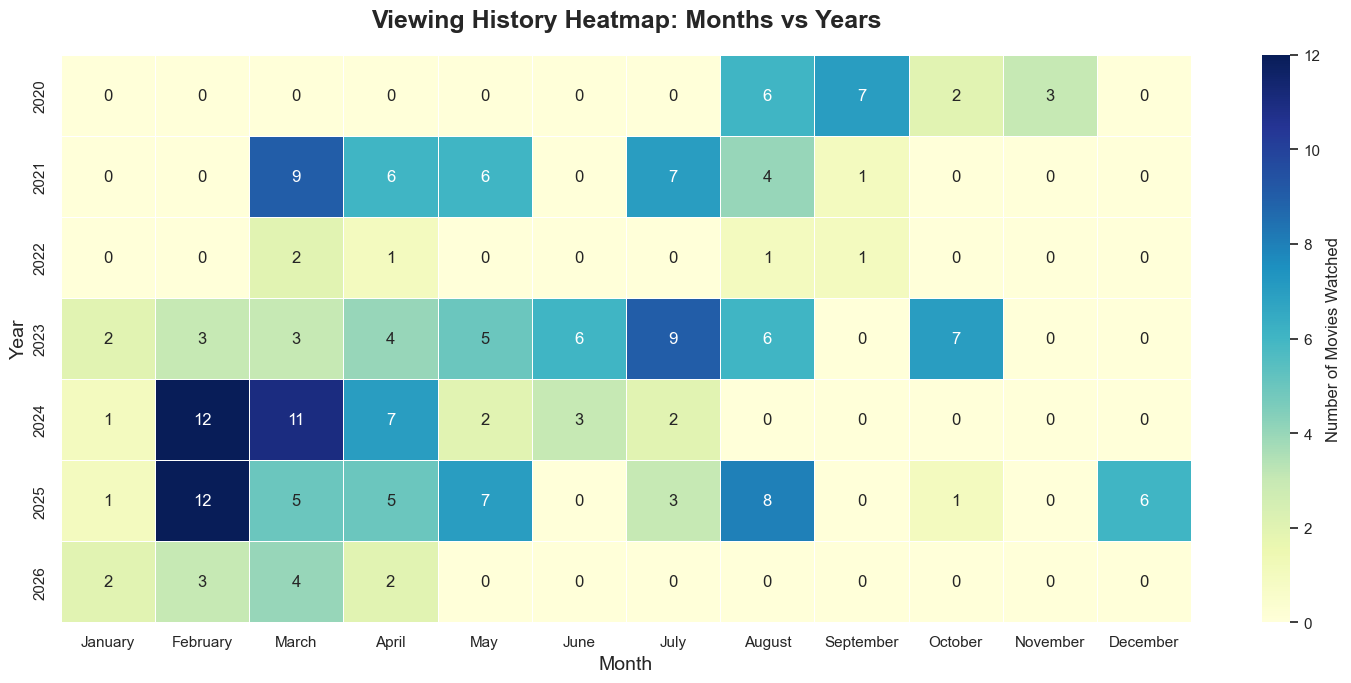

In [ ]:

# Load the cleaned data
df['Watched Date'] = pd.to_datetime(df['Watched Date'])

# Extract Year and Month Name
df['Year'] = df['Watched Date'].dt.year
df['Month'] = df['Watched Date'].dt.month_name()

# Create a pivot table: Rows = Years, Columns = Months
# We count how many movies fall into each Year/Month slot
pivot_table = df.groupby(['Year', 'Month']).size().unstack(fill_value=0)

# Reorder columns so months appear chronologically (Jan -> Dec)
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
# Filter the list to only include months that actually exist in your dataset
available_months = [m for m in month_order if m in pivot_table.columns]
pivot_table = pivot_table[available_months]

# Create the Heatmap
plt.figure(figsize=(15, 7))
sns.heatmap(
    pivot_table, 
    annot=True,      
    fmt="d",         
    cmap="YlGnBu",   # Yellow-Green-Blue color transition
    linewidths=.5,   # a small gap between squares
    cbar_kws={'label': 'Number of Movies Watched'}
)

plt.title('Viewing History Heatmap: Months vs Years', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Year', fontsize=14)
plt.tight_layout()
plt.show()


## 7. When Were These Movies Released?
This chart looks at the original release years of the movies I watched, showing whether I watch more older classics or brand-new releases.

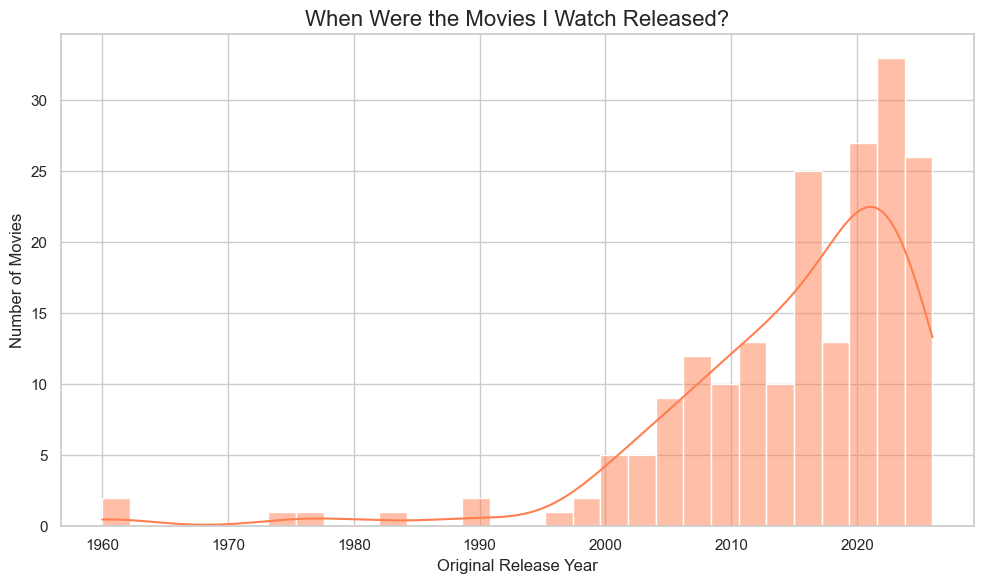

In [ ]:
plt.figure(figsize=(10, 6))
# Using a histogram with a Kernel Density Estimate to show the trend
sns.histplot(data=df, x='Year', bins=30, color='coral', kde=True)
plt.title('When Were the Movies I Watch Released?', fontsize=16)
plt.xlabel('Original Release Year', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Where Do My Movies Come From?
I was curious about my preferences regarding the origin country of each movie. Using the Country data that I already fetched from the TMDB API during the data preparation phase (Section 2), I can now map out the global footprint of my movie-watching habits.

In [ ]:

# Load the fully enriched dataset
df = pd.read_csv('Dataset/main_enrichedwithcountry_full.csv')

# Drop rows where Country is missing or 'Unknown'
df_countries = df[df['Country'].notna() & (df['Country'] != 'Unknown') & (df['Country'] != 'Error')].copy()

# Some movies have multiple countries (e.g., "France, Italy"). 
# We need to split them by the comma and create a separate row for each country
df_countries['Country'] = df_countries['Country'].str.split(', ')
df_exploded = df_countries.explode('Country')

# Count how many movies belong to each country
country_counts = df_exploded['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Movie Count']


# Create an interactive Choropleth Map using Plotly
fig = px.choropleth(
    data_frame=country_counts,
    locations='Country',
    locationmode='country names', # Plotly automatically matches the text names to the map!
    color='Movie Count',
    color_continuous_scale='Viridis', # A great preattentive color palette
    title='Global Footprint of My Movie Viewing Habits',
    labels={'Movie Count': 'Number of Movies'}
)

# Update layout for a cleaner look
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='equirectangular'
    ),
    title_font_size=18,
    title_x=0.5 # Centers the title
)

# Show the interactive map in the notebook
fig.show()


/var/folders/4t/r2dg52q53m5_t64tj26d8ljm0000gn/T/ipykernel_11817/1792821805.py:22: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


## 9. Reviews vs. Ratings
Analyzing how many written reviews I leave for each star rating level, to see if there's a pattern or relation.

/var/folders/4t/r2dg52q53m5_t64tj26d8ljm0000gn/T/ipykernel_11817/496832125.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=review_counts_per_rating.index, y=review_counts_per_rating.values, palette='plasma')


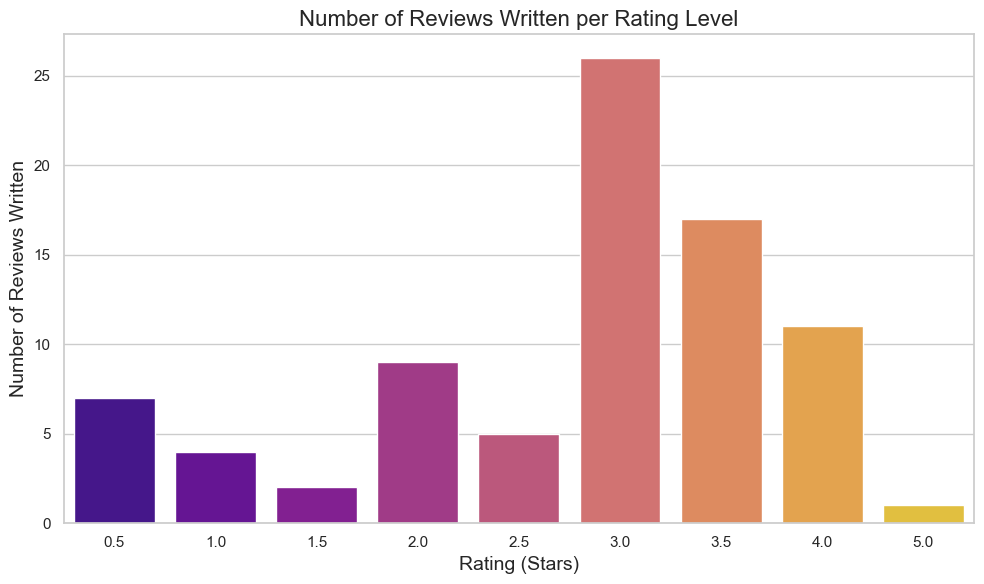

Total movies with reviews: 82


In [99]:
# Filter for movies that have reviews (Review is not null and not empty)
df_with_reviews = df[df['Review'].notna() & (df['Review'].str.strip() != '')].copy()

# Count reviews per rating level
review_counts_per_rating = df_with_reviews['Rating'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=review_counts_per_rating.index, y=review_counts_per_rating.values, palette='plasma')
plt.title('Number of Reviews Written per Rating Level', fontsize=16)
plt.xlabel('Rating (Stars)', fontsize=14)
plt.ylabel('Number of Reviews Written', fontsize=14)

plt.tight_layout()
plt.show()

print(f"Total movies with reviews: {len(df_with_reviews)}")

## Same data, another visualization

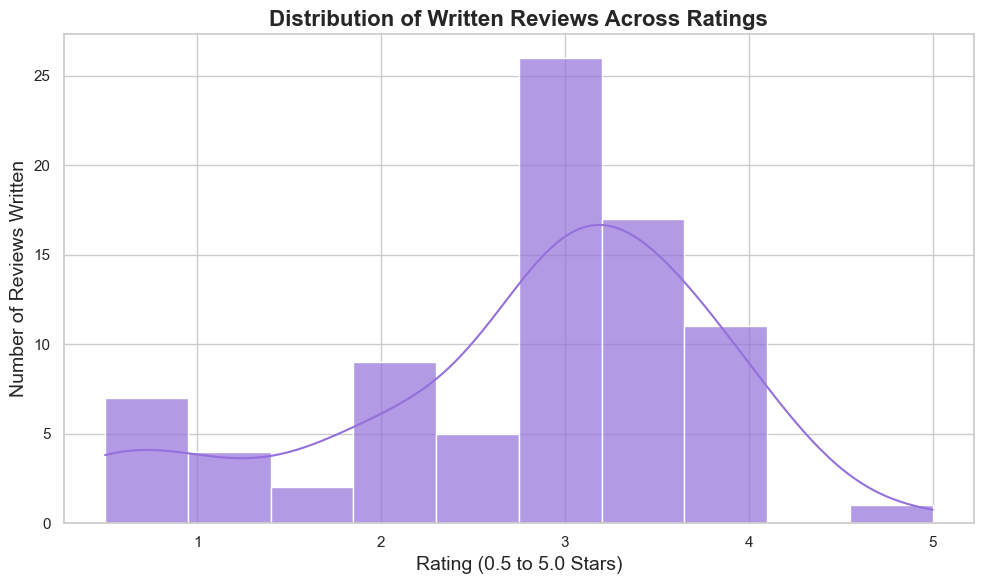

Total movies with reviews: 82


In [ ]:
# Filter for movies that have reviews (Review is not null and not empty)
df_with_reviews = df[df['Review'].notna() & (df['Review'].str.strip() != '')].copy()

plt.figure(figsize=(10, 6))

# Using a histogram with KDE 
# bins=10  because ratings go from 0.5 to 5.0 in half-steps (10 possible values)
sns.histplot(data=df_with_reviews, x='Rating', bins=10, color='mediumpurple', kde=True, alpha=0.7)

plt.title('Distribution of Written Reviews Across Ratings', fontsize=16, fontweight='bold')
plt.xlabel('Rating (0.5 to 5.0 Stars)', fontsize=14)
plt.ylabel('Number of Reviews Written', fontsize=14)

plt.tight_layout()
plt.show()

print(f"Total movies with reviews: {len(df_with_reviews)}")

## 10.A How Long are my Reviews?
I wanted to see if I write longer reviews for movies I love or hate.

/var/folders/4t/r2dg52q53m5_t64tj26d8ljm0000gn/T/ipykernel_11817/340614053.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


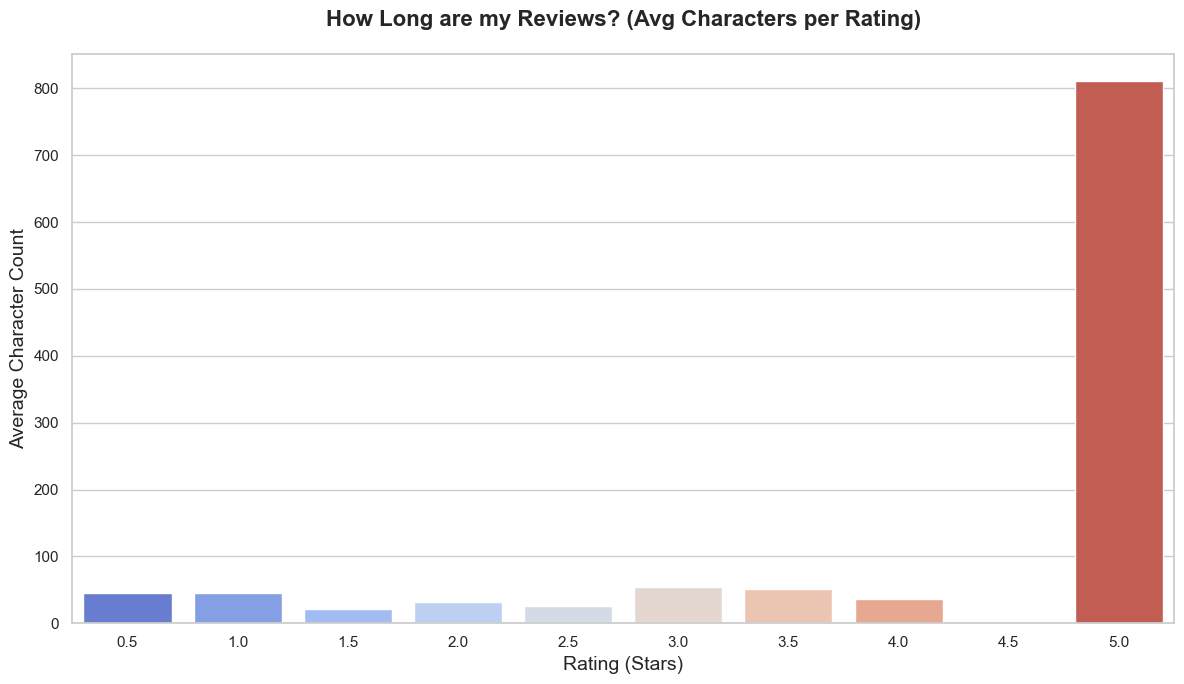


--- Average Review Length per Rating ---
Rating
0.5     44.9
1.0     45.2
1.5     22.0
2.0     31.2
2.5     25.2
3.0     54.6
3.5     51.9
4.0     35.7
5.0    811.0
Name: Review Length, dtype: float64


In [ ]:

# 1. Load the Data
df = pd.read_csv('Dataset/main_enrichedwithcountry_full.csv')

# 2. Filter for movies that actually have reviews
df_reviews = df[df['Review'].notna() & (df['Review'].str.strip() != '')].copy()

# 3. Calculate the character count for each review
df_reviews['Review Length'] = df_reviews['Review'].str.len()

# Define the full rating scale to force all columns to appear
rating_order = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

# 4. Create the Visualization
plt.figure(figsize=(12, 7))

# a barplot which shows the average length per rating category
sns.barplot(
    data=df_reviews, 
    x='Rating', 
    y='Review Length', 
    order=rating_order, 
    palette='coolwarm',
    estimator='mean', 
    errorbar=None      
)

# Formatting
plt.title('How Long are my Reviews? (Avg Characters per Rating)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Rating (Stars)', fontsize=14)
plt.ylabel('Average Character Count', fontsize=14)

plt.tight_layout()
plt.show()

# Print the exact numbers
print("\n--- Average Review Length per Rating ---")
print(df_reviews.groupby('Rating')['Review Length'].mean().round(1))

# 10.B Finding out and Removing the Outlier
Noticing that there was one massive outlier (a giant review for "Hello FatherDog") that was basically a quoeted review and not originally mine, ruined the scale of the chart, I decided to delete it and draw the graph again so the true, normal pattern is visible.

/var/folders/4t/r2dg52q53m5_t64tj26d8ljm0000gn/T/ipykernel_11817/2262202017.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Successfully created Dataset/main_cleaned.csv (outlier removed).


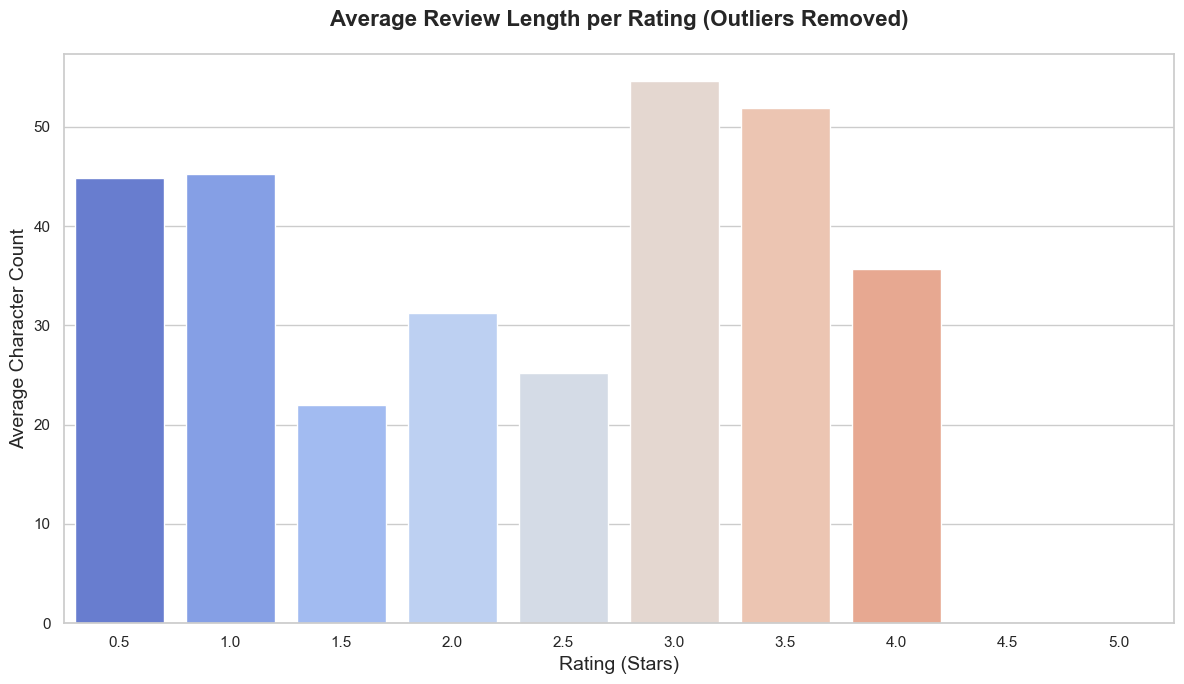

In [ ]:

# 1. Load the enriched data
df = pd.read_csv('Dataset/main_enrichedwithcountry_full.csv')

# 2. Remove the specific "Hello FatherDog" entry
df_cleaned = df[df['Name'] != 'Hello FatherDog'].copy()

# 3. Save the result to a new file
df_cleaned.to_csv('Dataset/main_cleaned.csv', index=False)
print("Successfully created Dataset/main_cleaned.csv (outlier removed).")

# 4. Prepare data for the review length chart
df_reviews = df_cleaned[df_cleaned['Review'].notna() & (df_cleaned['Review'].str.strip() != '')].copy()

# Calculate character count
df_reviews['Review Length'] = df_reviews['Review'].str.len()

# Define the full rating scale to force all columns to appear
rating_order = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

# 5. Create the Visualization
plt.figure(figsize=(12, 7))
sns.barplot(
    data=df_reviews, 
    x='Rating', 
    y='Review Length',
    order=rating_order, 
    palette='coolwarm',
    estimator='mean',
    errorbar=None
)

plt.title('Average Review Length per Rating (Outliers Removed)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Rating (Stars)', fontsize=14)
plt.ylabel('Average Character Count', fontsize=14)

plt.tight_layout()
plt.show()

## 10.C Trend: Average Review Length per Rating
Using a line plot to focus strictly on the upward or downward trend of review length across the rating scale.

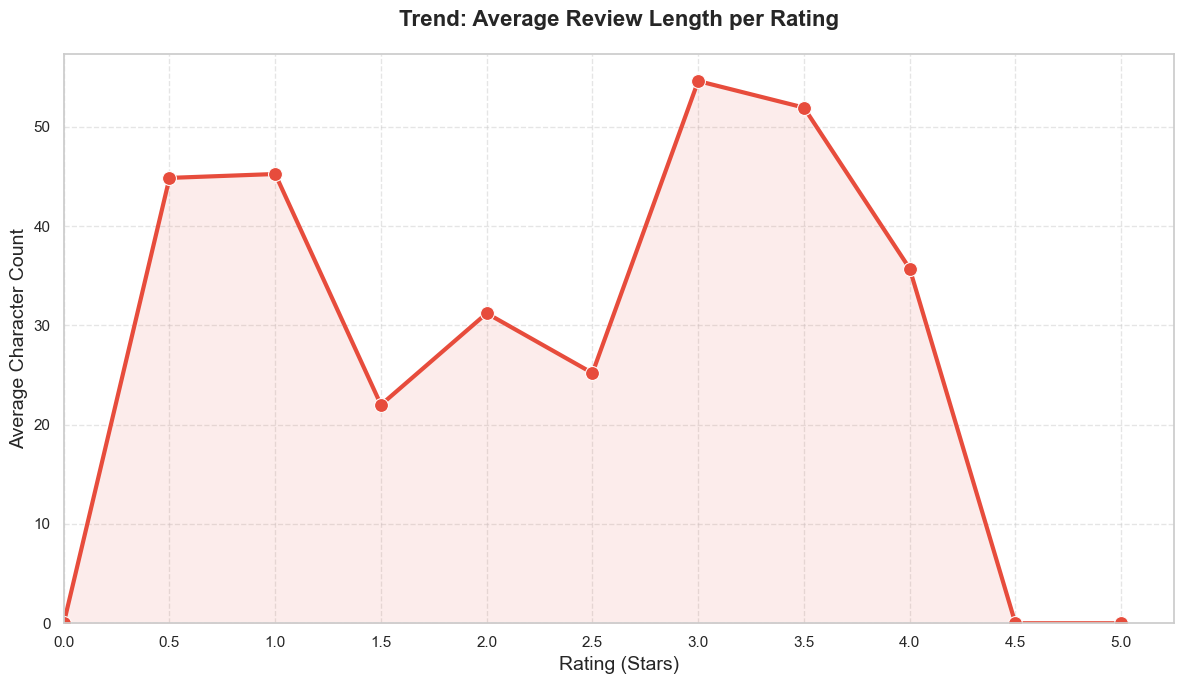

In [ ]:


# 1. Load the enriched data
df = pd.read_csv('Dataset/main_enrichedwithcountry_full.csv')

# 2. Remove the specific "Hello FatherDog" entry
df_cleaned = df[df['Name'] != 'Hello FatherDog'].copy()

# 3. Prepare data for the review length chart
df_reviews = df_cleaned[df_cleaned['Review'].notna() & (df_cleaned['Review'].str.strip() != '')].copy()
df_reviews['Review Length'] = df_reviews['Review'].str.len()

# Group by rating to get the average for the line plot
avg_review_data = df_reviews.groupby('Rating')['Review Length'].mean().reset_index()

# Add 0.0 to the list to anchor the line
rating_scale = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
all_ratings = pd.DataFrame({'Rating': rating_scale})

# Merge our calculated averages onto this list. 
avg_review_data = pd.merge(all_ratings, avg_review_data, on='Rating', how='left').fillna(0)

# 4. Create the Line Graph Visualization
plt.figure(figsize=(12, 7))

# Use lineplot to show the trend across ratings
sns.lineplot(
    data=avg_review_data, 
    x='Rating', 
    y='Review Length', 
    marker='o',          
    markersize=10, 
    linewidth=3, 
    color='#e74c3c'      
)

plt.fill_between(avg_review_data['Rating'], avg_review_data['Review Length'], color='#e74c3c', alpha=0.1)

# Aesthetics
plt.title('Trend: Average Review Length per Rating', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Rating (Stars)', fontsize=14)
plt.ylabel('Average Character Count', fontsize=14)

plt.xticks(rating_scale)
plt.grid(True, linestyle='--', alpha=0.5)


plt.xlim(left=0)   
plt.ylim(bottom=0) 

plt.tight_layout()
plt.show()

## 10.D Average Review Length per Rating (Combined Chart)

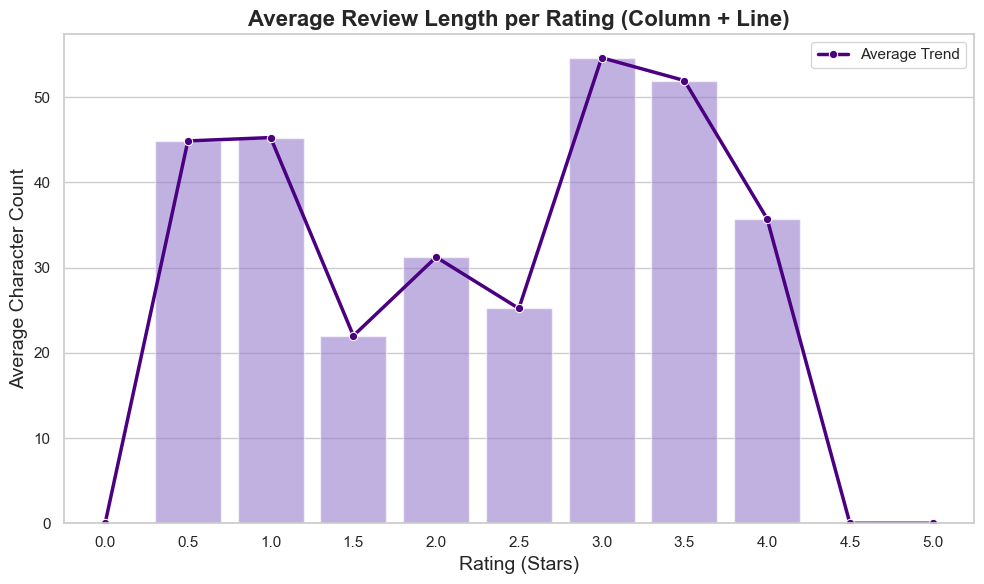

Analysis based on 81 written reviews.


In [ ]:


# 1. Load the enriched data (assuming this is your main working file)
df = pd.read_csv('Dataset/main_enrichedwithcountry_full.csv')

# 2. Prepare the data (removing the outlier and filtering for reviews)
df_cleaned = df[df['Name'] != 'Hello FatherDog'].copy()
df_reviews = df_cleaned[df_cleaned['Review'].notna() & (df_cleaned['Review'].str.strip() != '')].copy()
df_reviews['Review Length'] = df_reviews['Review'].str.len()

# 3. Calculate the average length per rating for the line
avg_data = df_reviews.groupby('Rating')['Review Length'].mean().reset_index()

# Include 0.0 at the beginning of the scale
rating_scale = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
all_ratings = pd.DataFrame({'Rating': rating_scale})

# Merge to fill missing ratings (including 0.0) with 0
avg_data = pd.merge(all_ratings, avg_data, on='Rating', how='left').fillna(0)

plt.figure(figsize=(10, 6))

# Average Length
sns.barplot(
    data=df_reviews, 
    x='Rating', 
    y='Review Length', 
    order=rating_scale, 
    color='mediumpurple', 
    alpha=0.6, 
    errorbar=None,
    estimator='mean'
)

# Trend
sns.lineplot(
    data=avg_data, 
    x=avg_data.index, 
    y='Review Length', 
    color='indigo', 
    marker='o', 
    linewidth=2.5, 
    label='Average Trend'
)

# 3. Aesthetics 
plt.title('Average Review Length per Rating (Column + Line)', fontsize=16, fontweight='bold')
plt.xlabel('Rating (Stars)', fontsize=14)
plt.ylabel('Average Character Count', fontsize=14)

# Force the bottom of the chart to anchor at zero
plt.ylim(bottom=0)

plt.legend()
plt.tight_layout()
plt.show()

print(f"Analysis based on {len(df_reviews)} written reviews.")

## 11.A In which months I leave more reviews?
I decided to do this chart to see if there's a pattern, and I decided to do it using the calender cgart, that worked well for movie watching pattern before. After seeing the rersult, I found out that there's no partecular trend, so I decided to checck it also per year.

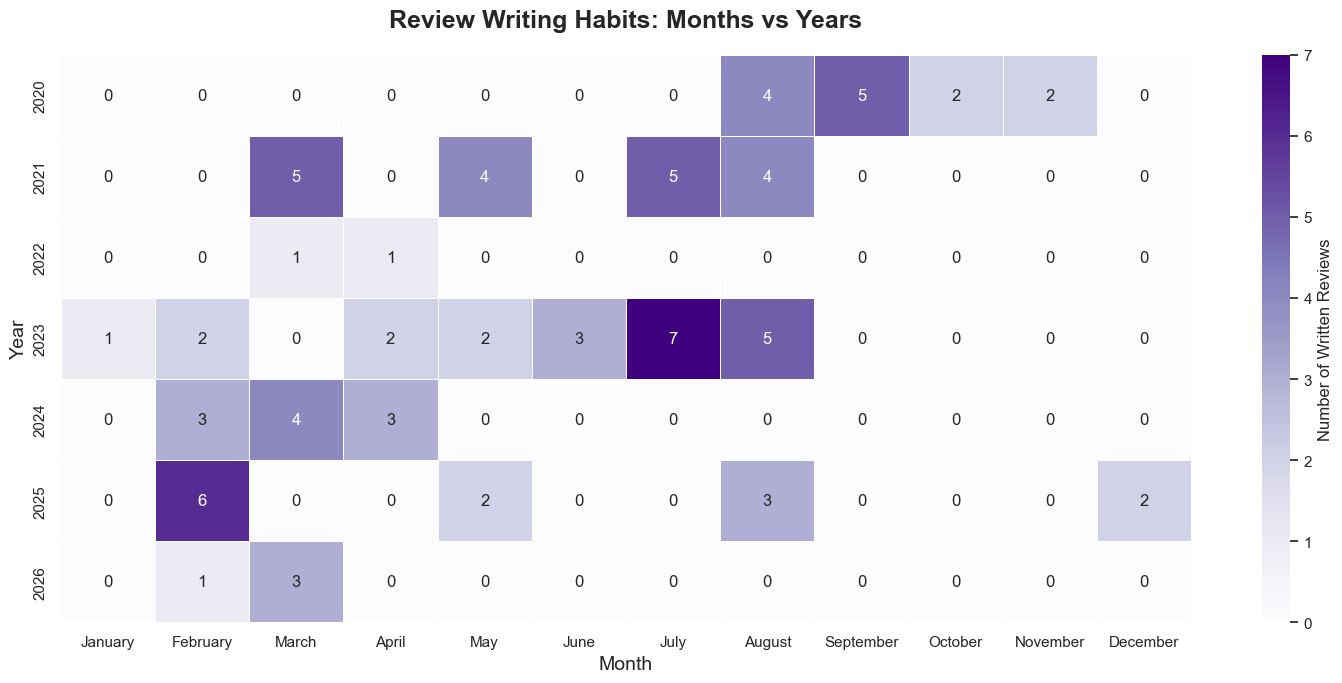

In [ ]:


# 1. Filter for movies that actually have written reviews
df_reviews_only = df[df['Review'].notna() & (df['Review'].str.strip() != '')].copy()

# 2. Make sure we have the Year and Month extracted
df_reviews_only['Watched Date'] = pd.to_datetime(df_reviews_only['Watched Date'])
df_reviews_only['Year'] = df_reviews_only['Watched Date'].dt.year
df_reviews_only['Month'] = df_reviews_only['Watched Date'].dt.month_name()

# 3. Create a pivot table: Rows = Years, Columns = Months
# We count how many reviews fall into each Year/Month slot
review_pivot = df_reviews_only.groupby(['Year', 'Month']).size().unstack(fill_value=0)

# 4. Reorder columns so months appear chronologically (Jan -> Dec)
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

available_months = [m for m in month_order if m in review_pivot.columns]
review_pivot = review_pivot[available_months]

# 5. Create the Heatmap
plt.figure(figsize=(15, 7))
sns.heatmap(
    review_pivot, 
    annot=True,      # Shows the actual numbers in each square
    fmt="d",         # Formats numbers as integers
    cmap="Purples",  # A purple color transition to distinguish from the viewing heatmap
    linewidths=.5,   # Adds a small gap between squares
    cbar_kws={'label': 'Number of Written Reviews'}
)

plt.title('Review Writing Habits: Months vs Years', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Year', fontsize=14)
plt.tight_layout()
plt.show()

## 11.B How Many Reviews Do I Write Each Year?
After looking at my monthly habits, I also wanted to see how my review-writing has changed over the years. This bar chart counts exactly how many reviews I wrote each year, making it easy to spot the years I was most active at logging my thoughts. The results showed that the year that I was the most active is 2023, which connecting it to my "Movies watched per year" chart, shows that, although 2023 was not the year that I had watched the major portion of movies, bit I was tending to leave more reviews.

/var/folders/4t/r2dg52q53m5_t64tj26d8ljm0000gn/T/ipykernel_11817/4257275019.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


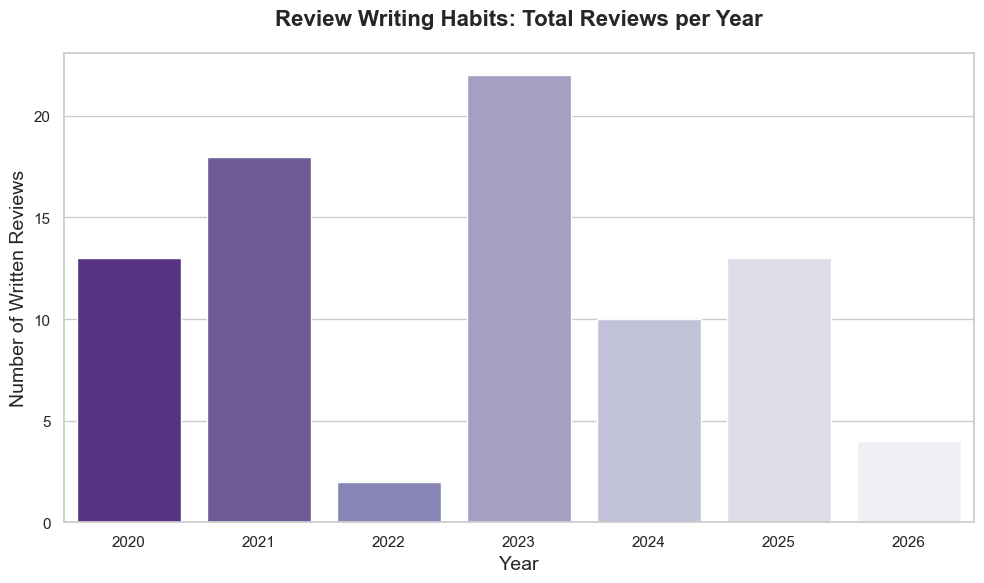

In [ ]:

# 1. Load the data (if not already loaded in memory)
df = pd.read_csv('Dataset/main_enrichedwithcountry_full.csv')

# 2. Filter for movies that actually have written reviews
df_reviews_only = df[df['Review'].notna() & (df['Review'].str.strip() != '')].copy()

# 3. Make sure we have the Year extracted
df_reviews_only['Watched Date'] = pd.to_datetime(df_reviews_only['Watched Date'])
df_reviews_only['Year'] = df_reviews_only['Watched Date'].dt.year

# 4. Count how many reviews were written each year and sort chronologically
reviews_per_year = df_reviews_only['Year'].value_counts().sort_index()

# 5. Create the Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(
    x=reviews_per_year.index.astype(int), 
    y=reviews_per_year.values, 
    palette='Purples_r' # Using purple to match the review heatmap!
)

# Formatting the chart
plt.title('Review Writing Habits: Total Reviews per Year', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Written Reviews', fontsize=14)
plt.tight_layout()

# Show the plot
plt.show()

## 12. Rating Trends Over Time
After looking at my ratings overall, I wanted to see how my scoring habits have changed over the years. Are my standards getting higher, or am I becoming more generous?

To answer this, I calculated my average rating for each year and plotted it on a line chart. I also created a heatmap to show the exact breakdown of how many 1-star, 3-star, or 5-star ratings I gave in any specific year, which I thought would be a better idea than stacked bar chart, to compare the rates per year.

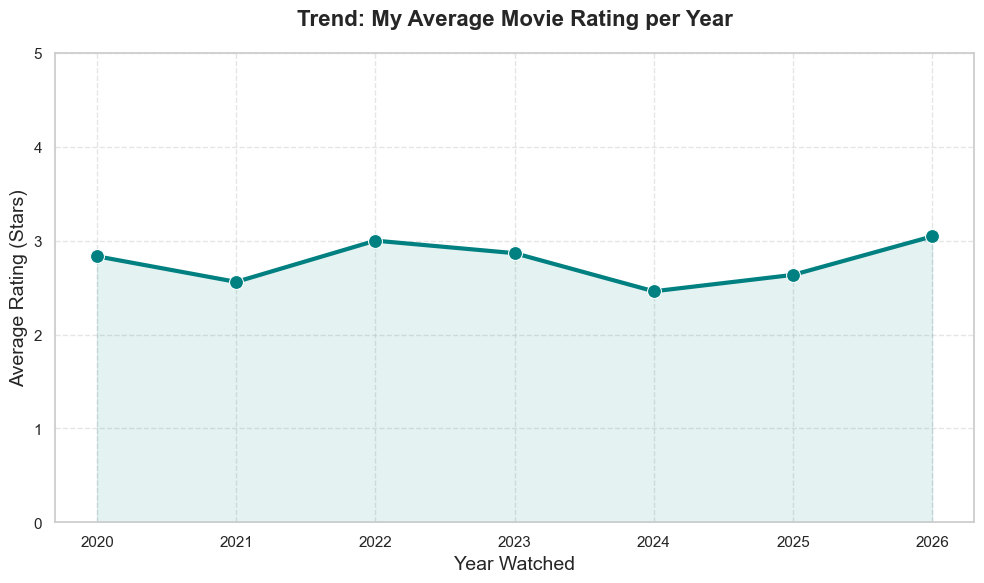

In [ ]:

# 1. Load the Data
df = pd.read_csv('Dataset/main_enrichedwithcountry_full.csv')
df['Watched Date'] = pd.to_datetime(df['Watched Date'])
df['Watched Year'] = df['Watched Date'].dt.year

# 2. Calculate the average rating per year
avg_rating_year = df.groupby('Watched Year')['Rating'].mean().reset_index()

# 3. Create the Line Chart
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=avg_rating_year, 
    x='Watched Year', 
    y='Rating', 
    marker='o', 
    color='teal', 
    linewidth=3, 
    markersize=10
)

# Add a soft shaded area under the line
plt.fill_between(avg_rating_year['Watched Year'], avg_rating_year['Rating'], color='teal', alpha=0.1)

# Formatting
plt.title('Trend: My Average Movie Rating per Year', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year Watched', fontsize=14)
plt.ylabel('Average Rating (Stars)', fontsize=14)

# Force the X-axis to show only whole years (no decimals like 2023.5)
plt.xticks(avg_rating_year['Watched Year'].astype(int))

# Force the Y-axis to represent the full Letterboxd scale (0 to 5)
plt.ylim(0, 5.0)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

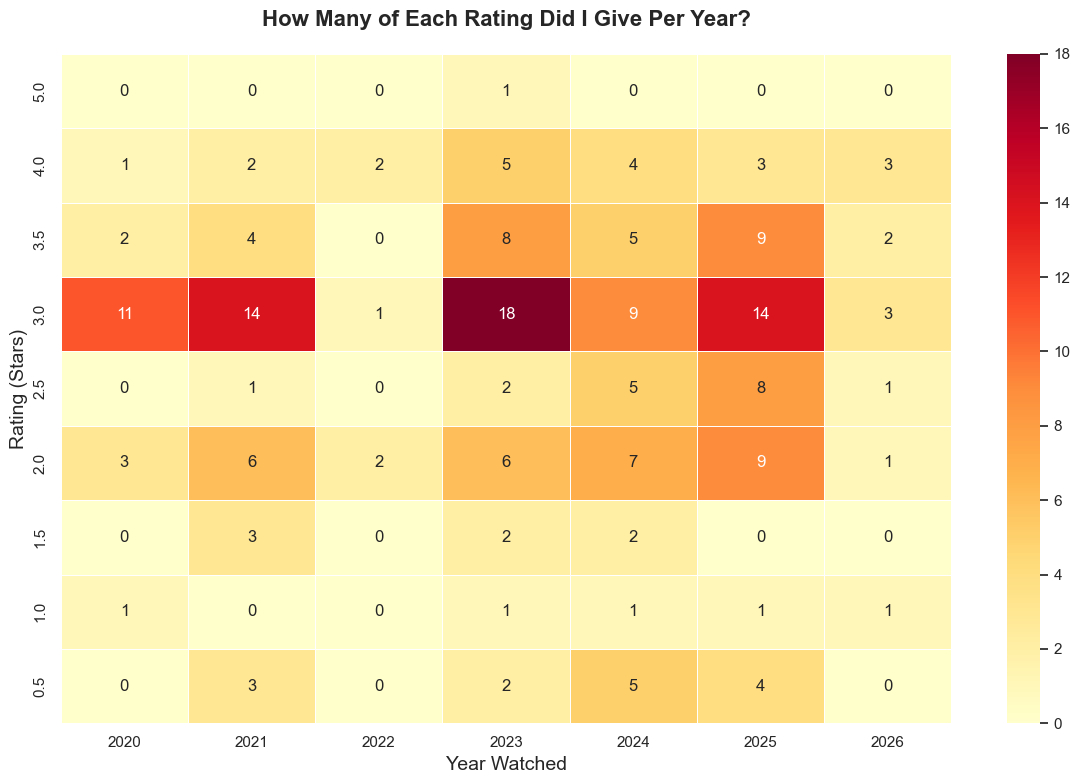

In [ ]:


# 1. Load the Data
df = pd.read_csv('Dataset/main_enrichedwithcountry_full.csv')
df['Watched Date'] = pd.to_datetime(df['Watched Date'])
df['Watched Year'] = df['Watched Date'].dt.year

# 2. Create a pivot table: Rows = Ratings, Columns = Years
# We count how many movies fall into each Rating/Year slot
rating_year_pivot = df.groupby(['Rating', 'Watched Year']).size().unstack(fill_value=0)

# Sort the ratings so 5.0 is at the top of the chart and 0.5 is at the bottom
rating_year_pivot = rating_year_pivot.sort_index(ascending=False)

# 3. Create the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    rating_year_pivot, 
    annot=True,      # exact number inside the square
    fmt="d",         # Formats numbers as whole integers
    cmap="YlOrRd",   # Yellow-Orange-Red color scheme
    linewidths=.5
)

# Formatting
plt.title('How Many of Each Rating Did I Give Per Year?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year Watched', fontsize=14)
plt.ylabel('Rating (Stars)', fontsize=14)

plt.tight_layout()
plt.show()